# 3장 1강: 편향-분산 트레이드오프와 과적합/과소적합 진단

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 모델 복잡도와 과적합/과소적합의 관계를 확인합니다.

- 모델이 너무 단순할 때 나타나는 **고편향(과소적합)** 상태를 확인합니다.
- 모델이 너무 복잡할 때 나타나는 **고분산(과적합)** 상태를 확인합니다.
- `learning_curve()`를 이용하여 학습곡선을 확인합니다.
- `validation_curve()`를 이용하여 모델 복잡도에 따른 Train / Validation 성능 변화를 확인합니다.
- `train-valid gap`을 이용하여 모델 상태를 진단합니다.
- 진단 결과에 맞는 대응 전략을 선택합니다.

> 이 실습에서는 3장 1강 교안에서 다룬 편향-분산, 학습곡선, 검증곡선, train-valid gap, 과적합/과소적합 대응 전략만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- numpy
- matplotlib
- scikit-learn
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 여러 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

이번 강의의 목적은 예측 성능 자체를 최대화하는 것이 아니라 **모델 복잡도에 따라 Train / Validation 성능이 어떻게 달라지는지 진단하는 것**입니다.

### 사용할 특성

결측치 처리 자체가 이번 강의의 학습 목표가 아니므로, 결측치가 없는 숫자형 특성 중 일부만 사용합니다.

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `TotalBsmtSF`
- `1stFlrSF`
- `YearBuilt`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 특성과 예측 대상을 선택합니다.
3. 결측치가 없는지 확인합니다.
4. 데이터 크기와 기초 통계량을 확인합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve, validation_curve

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

X = house[features]
y = house["SalePrice"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

print("\n[기초 통계량]")
display(X.describe())

X 크기: (1460, 6)
y 크기: (1460,)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0



[기초 통계량]


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1162.626712,1971.267808
std,1.382997,525.480383,0.747315,438.705324,386.587738,30.202904
min,1.000000,334.000000,0.000000,0.000000,334.000000,1872.000000
25%,5.000000,1129.500000,1.000000,795.750000,882.000000,1954.000000
50%,6.000000,1464.000000,2.000000,991.500000,1087.000000,1973.000000
75%,7.000000,1776.750000,2.000000,1298.250000,1391.250000,2000.000000
max,10.000000,5642.000000,4.000000,6110.000000,4692.000000,2010.000000


In [2]:
#스무고개!!

# 편향: 학습 데이터를 바꾸어 여러 번 생성한 모델의 평균적인 예측이 실제 관측에서 체계적으로 벗어나는 정도
# -> 실제 매출이 광고비에 따라 비선형적 형태로 변하는데, 선형 회귀를 사용하여 직선 하나로만 예측을 한다고 가정했을 때
# -> 고객 데이터를 바꾸어도 비슷한 구간에서 지속적으로 틀린다면 편향을 고려해볼 수 있다.

# 분산: 학습 데이터가 바뀌었을 때 같은 입력에 대한 모델 예측이 달라지는 정도
# -> 성별, 목소리 2가지 힌트를 가지고 DS반의 영준님을 특정할 수 있다.
# -> 성별, 목소리, 키, AI역량평가 1차, 2차, 생일 등의 다양한 힌트를 가지고 DS반의 종원님을 특정할 수 있다.
# 힌트가 많아졌을 때 맞추는 능력이 바뀌는 정도

# 과소적합: 모델이 학습 데이터의 패턴을 충분하게 파악하지 못함
# -> 보통 Decision Tree에서 트리 깊이를 1정도로 하여 충분한 패턴을 학습하지 못할 때에 발생할 수 있다.(스무고개에서 첫 질문에 맞추길 바라는 것)
# 행 수와 컬럼을 늘려서 해결하고자 함

# 과적합: 모델이 학습의 우연한 패턴까지 학습하여 새로운 데이터에 대한 적응력이 떨어짐
# 사탕: 포도맛, 망고맛, 콜라맛, 레몬맛
# 산미: 0.1, 0.4, 0.05, 0.7
# -> 모델이 0.1 = 포도맛이라고 정답을 외워버리는 경우
# -> 새롭게 포도맛(0.15)가 추가되면 못 맞춤

# 노이즈: 패턴이 없이 우연한 변동이나 측정 오차가 있는 경우
# -> 평상시에 구매가 없던 A고객이 갑자기 구매하는 경우
# -> 1월 온도가 한 낮에 20도까지 오른 경우

# 하이퍼파라미터: 학습 방법이나 모델의 구조를 정하기 위해 사람이 설정하는 값
# -> epoch, learn_rate 등의 비율을 설정

# 하이퍼파라미터 튜닝: 여러 설정값의 후보를 통해 좋은 성능을 찾는 최적화 과정
# -> Epoch(학습횟수) : 1 vs 10 | 나는 5번만 공부할래 -> 5
# -> Learn_rate(학습률) : 24 vs 2.4 | 나는 6시간씩 할래 -> 6
# -> 모델의 성능을 더 높이기 위해서 학습률이나 학습횟수 등을 바꾸어 결과를 더 높이는 최적의 모델을 찾는 과정

# 규제(Regularization): 모델이 데이터에 지나치게 맞추어 결과를 내지 않도록 학습에 제약을 주는 방법
# 사탕: 포도맛, 망고맛, 콜라맛, 레몬맛
# 산미: 0.1, 0.4, 0.05, 0.7
# 색: 보라색, 주황색, 검은색, 노란색
# -> 모델이 0.1 = 포도맛이라고 정답을 외워버리는 경우 -> 정답률이 100%라면 굳이 다른 힌트를 보지 않고 안바꿈
# -> 산미만 보고 포도맛이라는 걸 예측했다면 다른 컬럼은 무의미해짐
# -> 모델에 대한 해석이 떨어질 가능성이 있음

# 학습곡선: 학습성능과 검증성능의 변화를 학습 진행에 따라 그래프로 나타낸 값
# -> 모의고사 공부시간을 늘릴때마다 10점씩 상승했고
# -> 실전 모의고사 공부를 해보니 10점씩 상승했다.

---

# 필수 1. 학습곡선으로 과소적합과 과적합 진단

## 배경

학습곡선은 **학습 데이터의 양을 늘려가며 Train score와 Validation score가 어떻게 변하는지 확인하는 그래프**입니다.

이번 문제에서는 같은 Ames Housing 데이터에 대해 두 개의 결정트리를 비교합니다.

- `max_depth=2` → 복잡도가 낮은 모델
- `max_depth=None` → 깊이를 제한하지 않은 복잡한 모델

## 문제 1. `max_depth=2` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=2, random_state=42)`를 만듭니다.
2. `learning_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 학습 데이터 비율은 `np.linspace(0.1, 1.0, 6)`을 사용합니다.
5. 각 구간의 Train score와 Validation score 평균을 계산합니다.
6. 두 점수를 하나의 그래프에 표시합니다.
7. 두 곡선이 어디에서 수렴하는지 확인합니다.

### 확인 포인트

- 두 점수가 모두 낮은 수준에서 가까워지는가?
- 모델이 너무 단순한 상태인지 판단할 수 있는가?

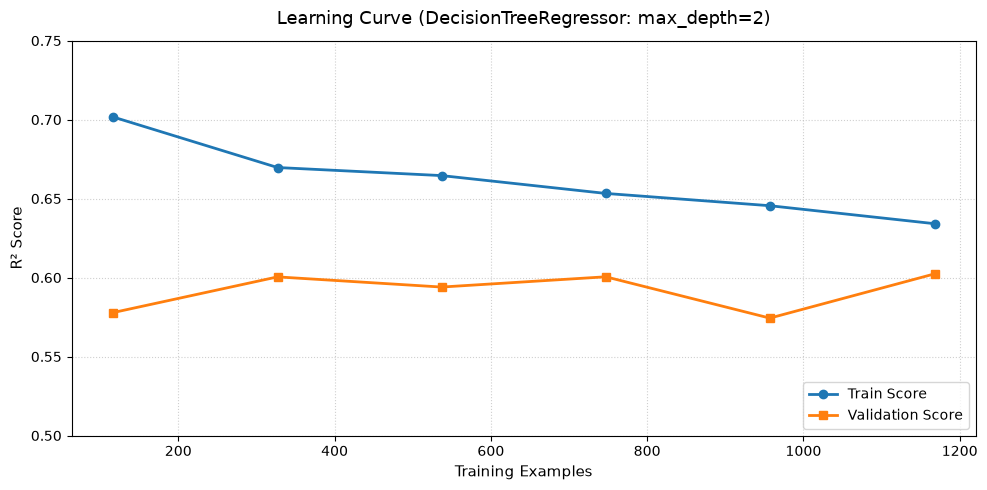

=== max_depth=2 학습곡선 최종 점수 (학습 데이터 100% 기준) ===
Train R² Score      : 0.6341
Validation R² Score : 0.6024
Train-Valid Gap     : 0.0317


In [3]:
# TODO
# max_depth=2 결정트리의 학습곡선을 그려보세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=2, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

train_sizes_abs, train_scores, valid_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=5,
    scoring="r2",
    random_state=42,
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

# 4. 시각화
plt.figure(figsize=(10, 5))
plt.plot(
    train_sizes_abs,
    train_mean,
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Train Score",
)
plt.plot(
    train_sizes_abs,
    valid_mean,
    marker="s",
    color="tab:orange",
    linewidth=2,
    label="Validation Score",
)

plt.title("Learning Curve (DecisionTreeRegressor: max_depth=2)", fontsize=13, pad=12)
plt.xlabel("Training Examples", fontsize=11)
plt.ylabel("R² Score", fontsize=11)
plt.ylim(0.5, 0.75)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

print("=== max_depth=2 학습곡선 최종 점수 (학습 데이터 100% 기준) ===")
print(f"Train R² Score      : {train_mean[-1]:.4f}")
print(f"Validation R² Score : {valid_mean[-1]:.4f}")
print(f"Train-Valid Gap     : {train_mean[-1] - valid_mean[-1]:.4f}")

- R2: 결정계수
- R2 = 1: 실제값과 예측값이 일치
- R2 = 0: 실제 평균만 예측, 충분히 설명하지 못함
###
- 학습 샘플 수 116 : Train R2의 평균 0.70 / Validation R2의 평균 0.57 -> 판단: 적은 학습 데이터에서 비교적 차이가 큼(0.13)
###
- 학습 샘플 수 327 : Train R2의 평균 0.66 / Validation R2의 평균 0.60 -> 판단: Train 데이터의 R2는 0.04감소, Validation의 R2는 0.03 상승, 격차가 줄었다.
###
- 학습 샘플 수 537 : Train R2의 평균 0.66 / Validation R2의 평균 0.59 -> 판단: Train R2는 유지, Validation R2는 0.01 감소
###
- 학습 샘플 수 1,168: Train R2의 평균 0.63 / Validation R2의 평균 0.60 -> 판단: 평균 점수 차이가 가장 낮다
###
- 그렇다면 이 표와 그래프를 보고 과소적합 또는 편향의 신호를 알 수 있는가?
- -> R2값이 Train과 Validation에서 약 0.60 정도, 즉 데이터에 대한 파악이 약 60점 정도라고 보인다.
- -> R2값이 비교적 0.60으로 낮기 때문에 모델이 해당 데이터에 대한 충분한 파악을 하지 못한 과소적합을 의심해볼 수 있다.
- -> 단, R2가 0.60이면 무조건 낮으니까 과소적합이다 (X) -> 기준이 없기 때문에 추후 다른 평가지표나 그래프를 통해 근거를 강화해야함
###
- 해석 : max_depth 2의 결정트리는 최대 Fold의 학습 크기 1,168개에서 Train R2가 0.63, Validation R2가 0.60으로 차이가 가장 작았지만 R2가 낮아 과소적합을 의심해야한다.

### Q1. `max_depth=2` 모델은 과소적합과 과적합 중 어느 쪽에 더 가깝다고 볼 수 있나요?

**답변:**  
과소적합에 더 가깝다. Train과 Validation의 R2값이 모두 낮았으며 그 간격도 작았다.

## 문제 2. `max_depth=None` 모델의 학습곡선을 그리세요.

### 요구사항

1. `DecisionTreeRegressor(max_depth=None, random_state=42)`를 만듭니다.
2. 필수 1 문제 1과 동일한 방식으로 `learning_curve()`를 사용합니다.
3. Train score와 Validation score를 그래프로 나타냅니다.
4. 두 곡선 사이의 간격을 확인합니다.

### 확인 포인트

- Train score가 매우 높은가?
- Validation score와의 간격이 크게 유지되는가?
- 고분산(과적합) 신호를 확인할 수 있는가?

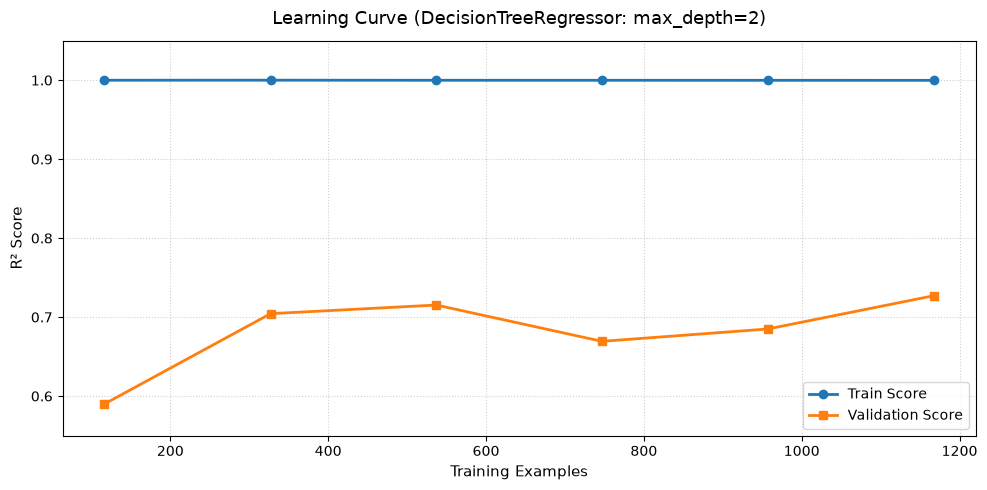

=== max_depth=2 학습곡선 최종 점수 (학습 데이터 100% 기준) ===
Train R² Score      : 0.9998
Validation R² Score : 0.7272
Train-Valid Gap     : 0.2726


In [4]:
# TODO
# max_depth=None 결정트리의 학습곡선을 그려보세요.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=None, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

train_sizes_abs, train_scores, valid_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=5,
    scoring="r2",
    random_state=42,
)

train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

# 4. 시각화
plt.figure(figsize=(10, 5))
plt.plot(
    train_sizes_abs,
    train_mean,
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Train Score",
)
plt.plot(
    train_sizes_abs,
    valid_mean,
    marker="s",
    color="tab:orange",
    linewidth=2,
    label="Validation Score",
)

plt.title("Learning Curve (DecisionTreeRegressor: max_depth=2)", fontsize=13, pad=12)
plt.xlabel("Training Examples", fontsize=11)
plt.ylabel("R² Score", fontsize=11)
plt.ylim(0.55, 1.05)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

print("=== max_depth=2 학습곡선 최종 점수 (학습 데이터 100% 기준) ===")
print(f"Train R² Score      : {train_mean[-1]:.4f}")
print(f"Validation R² Score : {valid_mean[-1]:.4f}")
print(f"Train-Valid Gap     : {train_mean[-1] - valid_mean[-1]:.4f}")

- 학습 샘플 수 116 : Train R2의 평균 0.99 / Validation R2의 평균 0.59 -> 판단: 적은 학습 데이터에서 비교적 차이가 큼(0.40)
###
- 학습 샘플 수 327 : Train R2의 평균 0.99 / Validation R2의 평균 0.70 -> 판단: 점수차이 0.29
###
- 학습 샘플 수 537 : Train R2의 평균 0.99 / Validation R2의 평균 0.71 -> 판단: 점수차이 0.28
###
- 학습 샘플 수 1,168: Train R2의 평균 0.99 / Validation R2의 평균 0.72 -> 판단: 점수차이 0.27
- -> 해당 학습 샘플 수를 선택하여 모델링하는 것이 유리
###
- Train R2가 평균 0.99라는 것의 의미: 매우 작은 제곱오차로 맞추고 있다.(극소한 차이까지 맞춤)
###
- Train R2와 Validation R2의 차이가 0.27이라는 것의 의미: Train의 점수는 0.99점이고 Validation의 점수는 0.27로 차이가 크다는 것은 과적합의 신호
- R2의 차이가 0.27이라고해서 27%만큼 Validation이 더 틀렸다는 해석은 틀렸다.
###
- 해석: 깊이 제한이 없는 트리 모델의 경우 Train R2이 거의 1에 가까움, 다만 Validation R2은 0.59 ~ 0.72까지 다양함
- 학습량 증가에 따른 Validation 개선의 여지가 보이지만 Train R2과 Validation R2의 격차를 줄이지 못해 과적합 가능성을 보고 다른 평가지표와 그래프 등을 확인해야한다. 
###
### Q2. `max_depth=None` 모델에서 데이터를 더 추가하는 것이 도움이 될 가능성이 있는 이유는 무엇인가요?

**답변:**  
- Valid Score가 데이터가 늘어남에 따라 우상향하는 추세를 보이므로, 데이터를 더 추가하면 성능 개선의 가능성이 있다.
- 과적합 상태에서는 모델이 현재 데이터를 지나치게 학습을 한 상태로 학습 데이터가 더 많아지면 현재 학습했던 패턴 외의 패턴들을 학습할 수가 있기 때문에
- Train과 Validation의 격차가 줄어들 수 있다.

---

# 필수 2. 검증곡선과 train-valid gap으로 최적 복잡도 확인

## 배경

검증곡선은 **모델의 하이퍼파라미터를 바꿔가며 Train score와 Validation score의 변화를 확인하는 그래프**입니다.

이번 문제에서는 결정트리의 `max_depth`를 바꾸어 모델 복잡도를 조절합니다.

## 문제 1. `max_depth` 검증곡선을 만드세요.

### 요구사항

1. 다음 `max_depth` 후보를 사용합니다.

```python
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]
```

2. `validation_curve()`를 사용합니다.
3. `cv=5`를 사용합니다.
4. 각 `max_depth`의 Train score와 Validation score 평균을 계산합니다.
5. `gap = train_mean - valid_mean`을 계산합니다.
6. `max_depth`, `train`, `validation`, `gap`을 DataFrame으로 만듭니다.
7. Train / Validation score를 하나의 그래프에 표시합니다.

### 확인 포인트

- 복잡도가 증가할수록 Train score가 어떻게 변하는가?
- Validation score는 어느 지점까지 좋아지고 이후 어떻게 변하는가?
- train-valid gap은 깊이가 커질수록 어떻게 변하는가?

=== max_depth별 검증 결과 및 Gap ===
max_depth  train validation    gap
        1 0.4545     0.4298 0.0247
        2 0.6341     0.6024 0.0317
        3 0.7336     0.6791 0.0545
        4 0.8115     0.7335 0.0780
        5 0.8624     0.7556 0.1068
        8 0.9482     0.7709 0.1773
       12 0.9898     0.7461 0.2437
       20 0.9997     0.7353 0.2644
     None 0.9998     0.7272 0.2726


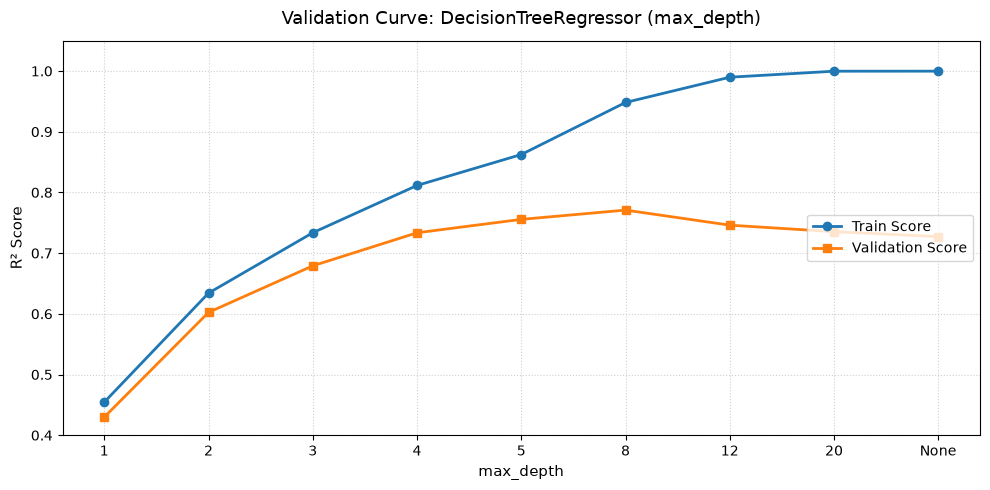

In [5]:
# TODO
# validation_curve()를 이용해 max_depth별 Train / Validation score와 gap을 확인하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeRegressor

# 1. 특성 및 타깃 지정 (필수 1과 동일)
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
]
target = "SalePrice"

X = house[features]
y = house["SalePrice"]

# 2. 파라미터 탐색 범위 설정
param_range = [1, 2, 3, 4, 5, 8, 12, 20, None]

# 3. validation_curve 실행 (cv=5, scoring='r2')
train_scores, valid_scores = validation_curve(
    estimator=DecisionTreeRegressor(random_state=42),
    X=X,
    y=y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="r2",
)

# 4. 각 max_depth별 Train / Validation score 평균 계산
train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)

# 5. gap = train_mean - valid_mean 계산
gap = train_mean - valid_mean

# 6. max_depth, train, validation, gap DataFrame 생성
# None 표기를 문자열 'None'으로 통일해 표시
param_labels = [str(p) for p in param_range]
results_df = pd.DataFrame(
    {
        "max_depth": param_labels,
        "train": train_mean,
        "validation": valid_mean,
        "gap": gap,
    }
)

print("=== max_depth별 검증 결과 및 Gap ===")
print(
    results_df.to_string(
        index=False,
        formatters={
            "train": "{:.4f}".format,
            "validation": "{:.4f}".format,
            "gap": "{:.4f}".format,
        },
    )
)

# 7. 검증곡선 시각화
plt.figure(figsize=(10, 5))
x_ticks = np.arange(len(param_range))

plt.plot(
    x_ticks,
    train_mean,
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Train Score",
)
plt.plot(
    x_ticks,
    valid_mean,
    marker="s",
    color="tab:orange",
    linewidth=2,
    label="Validation Score",
)

plt.title("Validation Curve: DecisionTreeRegressor (max_depth)", fontsize=13, pad=12)
plt.xlabel("max_depth", fontsize=11)
plt.ylabel("R² Score", fontsize=11)
plt.xticks(x_ticks, param_labels)
plt.ylim(0.4, 1.05)
plt.legend(loc="center right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

###
- 두 곡선의 목적을 구분
- 학습곡선과 검증곡선
- 학습곡선은 학습자료의 수를 바꾸고 검증곡선 max_depth를 바꾼다.
- 모델결과를 유지하려는 핵심 조건은 학습곡선은 트리 깊이 설정, 검증곡선은 데이터와 교차검증 분할
- 학습곡선의 메인 질문: 데이터가 늘어날수록 성능이 어떻게 달라지는가?
- 검증곡선의 메인 질문: 오차나 변동이 큰 경우 성능이 어떻게 달라지는가?


### Q3. Validation score가 가장 높은 `max_depth`는 무엇인가요?

**답변:**  
max_depth = 8

###
- Train R2와 Validation R2가 비교적 격차가 적으며 Valdation R2이 가장 높은 후보를 선택
- 해석: 복잡도를 높이면 Train R2는 계속 상승하지만 Validation R2는 깊이 8에서 0.77로 가낭 좊고 그 이후에 감소, 
- 깊이 1같은 경우 R2값이 Train과 Test에서 모두 낮아 과소적합을 의심해볼 수 있으며
- 매우 깊은 depth에서는 Train R2만 좋아져 과적합의 신호를 포착할 수 있다.
- 우선 가장 효과가 좋았던 depth 8을 검토해볼 수 있다.

### Q4. `max_depth`가 매우 커질수록 train-valid gap이 커지는 이유는 무엇인가요?

**답변:**  
- 결정트리가 깊어질수록 학습 데이터의 세부적인 패턴과 노이즈까지 학습을 하려고 하기 때문에 Train Score는 지속적으로 1에 가까워지고, 
- 새로운 데이터인 Validate에 대해서는 충분히 적응하지 못해서 성능이 떨어질 수 있다.

---

# 과제 1. 모델 상태를 진단하고 대응 전략 선택하기

## 배경

필수 실습에서는 학습곡선과 검증곡선을 이용해 모델의 상태를 확인했습니다.

이번 과제에서는 검증곡선 결과를 이용하여 세 가지 복잡도의 모델 상태를 직접 판단합니다.

> 과제는 필수 실습에서 확인한 결과를 해석하는 수준입니다.

## 문제

다음 세 모델을 확인하세요.

- `max_depth=1`
- `max_depth=8`
- `max_depth=None`

### 요구사항

1. 필수 2에서 만든 `gap_df`에서 세 모델의 Train score, Validation score, gap을 확인합니다.
2. 각 모델을 다음 중 하나로 진단합니다.
   - 과소적합
   - 비교적 적절한 복잡도
   - 과적합
3. 각 모델의 진단 근거를 Train score, Validation score, gap을 이용해 설명합니다.
4. 과소적합 또는 과적합 모델에 대해 교안에서 배운 대응 전략 중 적절한 방향을 하나 이상 작성합니다.

### 확인 포인트

- 점수가 낮고 gap이 작은 경우를 과소적합으로 해석할 수 있는가?
- Train score만 매우 높고 gap이 큰 경우를 과적합으로 해석할 수 있는가?
- Validation score가 높고 gap이 지나치게 크지 않은 지점을 적절한 후보로 볼 수 있는가?
- 진단 후에 대응 전략을 선택했는가?

In [14]:
# TODO
# gap_df에서 max_depth=1, 8, None에 해당하는 결과를 확인하세요.
# gap_df에서 max_depth가 1, 8, None인 행 필터링 및 확인

# max_depth가 1, 8, None인 행 필터링
subset = gap_df[gap_df["max_depth"].isin([1, 8, None])]
display(subset)

# param_range = [1, 2, 3, 4, 5, 8, 12, 20, None] 기준 인덱스: 0(1), 5(8), 8(None)
display(gap_df.iloc[[0, 5, -1]])

,max_depth,train_score,valid_score,gap
0,1.0,0.454464,0.429791,0.024674
5,8.0,0.948189,0.770884,0.177305


,max_depth,train_score,valid_score,gap
0,1.0,0.454464,0.429791,0.024674
5,8.0,0.948189,0.770884,0.177305
8,NaN,0.999768,0.727192,0.272575


### Q5. 세 모델의 상태를 각각 진단하세요.

| max_depth | 진단 | 근거 |
|---|---|---|
| 1 | 과소적합 | gap은 작지만 train / valid 점수가 모두 낮다 |
| 8 | 과적합 의심 | train 점수가 높고 gap이 0.177로 증가했다. |
| None | 과적합 | train 점수가 1에 거의 근접하며 gap이 0.27이상으로 매우 크다 |

### Q6. 과소적합 모델과 과적합 모델에 각각 어떤 대응 전략을 사용할 수 있나요?

**답변:**  
과소적합 모델은 학습량을 늘리기 위해 max_depth를 늘리는 방법을 사용할 수 있다. 반면 과적합 모델은 train 데이터를 과도하게 학습하여 노이즈 패턴까지 외운 것으로, max_depth를 낮추거나 feature selection으로 노이즈가 많거나 중요도가 낮은 특성을 제거하여 과도한 학습을 방지한다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 편향이 높은 모델은 일반적으로 과소적합과 과적합 중 어느 상태와 관련이 있나요?
- 일반적으로 과소적합과 관련이 있다.

2. 분산이 높은 모델은 일반적으로 어느 상태와 관련이 있나요?
- 일반적으로 과적합과 관련이 있다.

3. 학습곡선에서 Train과 Validation이 낮은 값에서 함께 수렴하면 어떤 상태인가요?
- 과소적합의 신호

4. Train score는 매우 높지만 Validation score가 낮고 gap이 크다면 어떤 상태인가요?
- 과적합의 신호

5. 검증곡선에서 Validation score가 가장 높은 지점은 어떤 의미를 가지나요?
- 현재 후보 중에서 새로운 데이터에 가장 적응을 잘 한 모델로 볼 수 있다. (유력!)

6. 과적합과 과소적합을 진단하지 않고 바로 처방하면 안 되는 이유는 무엇인가요?
- 과소적합과 과적합은 서로 반대되는 개념으로, 과소적합 모델은 더 단순하게 설계하거나, 과적합 모델은 더 복잡하게 만들면 문제가 커질 수 있다.
- 따라서 어떤 문제를 해결해야 하는지 명확하게 알고 대응해야한다.